  Starting RNN Concepts Demo


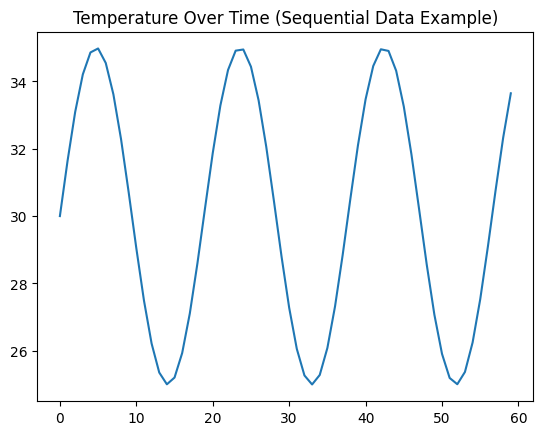


Shape of input for RNN: (55, 5, 1)
Example sequential input: [0.5011482  0.66512284 0.81104616 0.92285401 0.98823791]
Label to predict: 1.0

 Training Vanilla RNN (Many-to-One prediction)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Prediction using Vanilla RNN: [[0.9913677]]

 Demonstrating Many-to-Many RNN (equal length output)
Many-to-Many Prediction (one sequence):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
[0.50663006 0.6738494  0.7991297  0.9137835  0.9516193 ]

 Training LSTM
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Prediction using LSTM: [[0.6964782]]

 Training GRU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
Prediction using GRU: [[0.5120354]]

 Training Bidirectional LSTM


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
Prediction using BiLSTM: [[0.7384347]]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step 


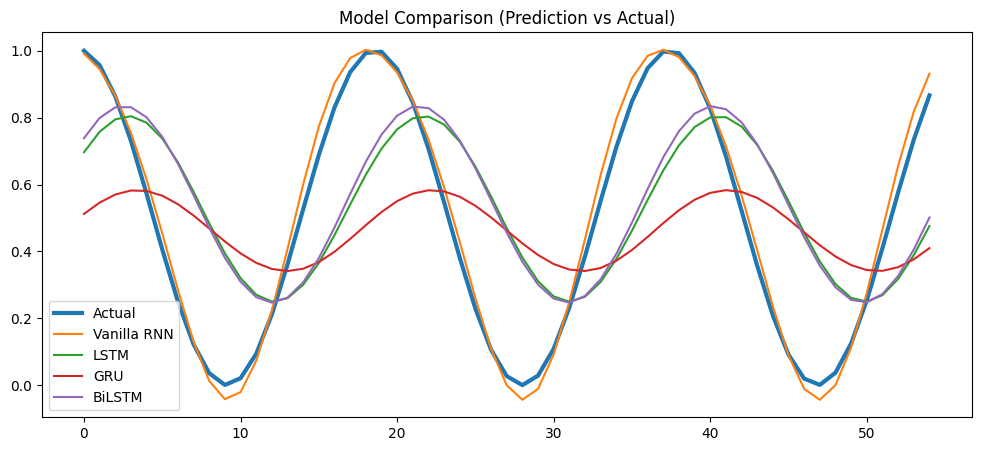


 Completed: RNN, LSTM, GRU, Bidirectional LSTM demonstrated.


In [ ]:
# ==========================================================
#   RNN Complete Demonstration (Concepts + Code)
#   Covers: Sequential Data | Vanilla RNN | LSTM | GRU | Bidirectional LSTM
#   Many-to-One | Many-to-Many | Training + Prediction
# ==========================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional, TimeDistributed
import matplotlib.pyplot as plt

print("  Starting RNN Concepts Demo")

# ------------------------------------------------------------
# 1 Create sequential dataset (Temperature over 60 days)
# ------------------------------------------------------------
days = np.arange(0, 60)
temp = 30 + np.sin(days / 3) * 5        # fluctuating temperature pattern

plt.plot(temp)
plt.title("Temperature Over Time (Sequential Data Example)")
plt.show()

# Normalize
temp = (temp - temp.min()) / (temp.max() - temp.min())
#neural networks work better when values are between 0 and 1 - otherwise trainings becomes slow and unstable.

# ------------------------------------------------------------
# Create dataset for RNN
# X = last 5 days temperature
# y = predict next temperature (Many-to-One)
# ------------------------------------------------------------

seq_len = 5  # window = 5 timesteps

X = []
y = []

for i in range(len(temp) - seq_len):
    X.append(temp[i:i+seq_len])
    y.append(temp[i+seq_len])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))   # reshape to RNN format (samples, time steps, features)

print("\nShape of input for RNN:", X.shape)
print("Example sequential input:", X[0].flatten())
print("Label to predict:", y[0])


# ------------------------------------------------------------
# 2 Vanilla RNN (Many-to-One)
# ------------------------------------------------------------

print("\n Training Vanilla RNN (Many-to-One prediction)")

model_rnn = Sequential([
    SimpleRNN(32, activation='tanh'),
    Dense(1)
])

model_rnn.compile(optimizer="adam", loss="mse")
model_rnn.fit(X, y, epochs=20, verbose=0)

print("Prediction using Vanilla RNN:", model_rnn.predict(X[:1]))


# ------------------------------------------------------------
# 3 MANY-TO-MANY (equal lengths) using TimeDistributed
# POS tagging type example (each timestep → output)
# ------------------------------------------------------------

print("\n Demonstrating Many-to-Many RNN (equal length output)")

model_many_to_many = Sequential([
    SimpleRNN(32, activation='tanh', return_sequences=True),
    TimeDistributed(Dense(1))
])

model_many_to_many.compile(optimizer="adam", loss="mse")
model_many_to_many.fit(X, X, epochs=20, verbose=0)

print("Many-to-Many Prediction (one sequence):")
print(model_many_to_many.predict(X[:1]).flatten())


# ------------------------------------------------------------
# 4 LSTM (better memory - solves vanishing gradient)
# ------------------------------------------------------------

print("\n Training LSTM")

model_lstm = Sequential([
    LSTM(32),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.fit(X, y, epochs=20, verbose=0)

print("Prediction using LSTM:", model_lstm.predict(X[:1]))


# ------------------------------------------------------------
# 5 GRU (faster, fewer gates than LSTM)
# ------------------------------------------------------------

print("\n Training GRU")

model_gru = Sequential([
    GRU(32),
    Dense(1)
])

model_gru.compile(optimizer="adam", loss="mse")
model_gru.fit(X, y, epochs=20, verbose=0)

print("Prediction using GRU:", model_gru.predict(X[:1]))


# ------------------------------------------------------------
# 6 Bidirectional LSTM (reads forward + backward)
# ------------------------------------------------------------

print("\n Training Bidirectional LSTM")

model_bilstm = Sequential([
    Bidirectional(LSTM(32)),
    Dense(1)
])

model_bilstm.compile(optimizer="adam", loss="mse")
model_bilstm.fit(X, y, epochs=20, verbose=0)

print("Prediction using BiLSTM:", model_bilstm.predict(X[:1]))


# ------------------------------------------------------------
# 7 Compare model performance visually
# ------------------------------------------------------------
models = ["Vanilla RNN", "LSTM", "GRU", "BiLSTM"]
preds = [
    model_rnn.predict(X).flatten(),
    model_lstm.predict(X).flatten(),
    model_gru.predict(X).flatten(),
    model_bilstm.predict(X).flatten(),
]

plt.figure(figsize=(12,5))
plt.plot(y, label="Actual", linewidth=3)
for m,p in zip(models, preds):
    plt.plot(p, label=m)

plt.title("Model Comparison (Prediction vs Actual)")
plt.legend()
plt.show()

print("\n Completed: RNN, LSTM, GRU, Bidirectional LSTM demonstrated.")
